# Wrist IMU Analytics for Strength Training
## Comparing three exercises and locating fatigue-sensitive regions of the Chest Press

**Sports Data Analytics group project**

A wrist-worn inertial measurement unit (IMU) records acceleration and angular velocity throughout an exercise set. This project first asks whether three exercises produce recognizably different sensor patterns. It then focuses on Chest Press: each detected pushing phase is split into a **first half** and a **second half** so that we can compare acceleration within repetitions, from early to late repetitions, and among sets.

> The phrase *candidate weak point* is used carefully. The IMU can reveal where acceleration becomes lower or deteriorates with fatigue, but it cannot identify a weak muscle or measure bar speed without external validation.

## Research questions

1. What does the dataset contain, and is it balanced across the three exercises?
2. Which movement characteristics distinguish Chest Press, Shoulder Press, and Lateral Raise?
3. Can simple IMU features recognize the exercise for a person not used during training?
4. During Chest Press, does the first or second half of the push show lower dynamic acceleration?
5. Which half deteriorates more from the beginning to the end of a set?
6. Are those patterns consistent among sets and repeated sets from the same participant?

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import GroupKFold, cross_val_predict, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from analysis import (
    ACC, GYR, CHEST, SHOULDER, LATERAL, EXERCISES,
    build_chest_half_features, build_recording_features,
    build_rep_comparison, build_set_comparison, detect_push_phases,
    load_data, load_signal,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False})
PALETTE = {CHEST: "#2878B5", SHOULDER: "#F39C35", LATERAL: "#4EAF49"}
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
recordings, samples = load_data()

# 1. Understanding the data

The dataset is a three-exercise subset of Microsoft RecoFit. `recordings.csv` has one row per set and contains the participant and labelled repetition count. `samples.csv` has one row per timestamp from the right-arm IMU. Acceleration is measured in *g* and angular velocity in degrees per second.

In [2]:
overview = recordings.groupby("activity_name").agg(
    sets=("record_uid", "count"),
    participants=("subject_id", "nunique"),
    labelled_reps=("activity_reps", "sum"),
    median_reps_per_set=("activity_reps", "median"),
).reindex(EXERCISES)

print(f"Recording-level table: {recordings.shape[0]} sets × {recordings.shape[1]} columns")
print(f"Sample-level table: {samples.shape[0]:,} timestamps × {samples.shape[1]} columns")
print(f"Missing sensor values: {samples[ACC + GYR].isna().sum().sum():,}")
print(f"Sets flagged incomplete by RecoFit: {(recordings.incomplete_data == 1).sum()}")
display(overview)

Recording-level table: 99 sets × 8 columns
Sample-level table: 232,046 timestamps × 10 columns
Missing sensor values: 0
Sets flagged incomplete by RecoFit: 2


,sets,participants,labelled_reps,median_reps_per_set
activity_name,,,,
Chest Press (rack),31,21,495,16.0
Squat Rack Shoulder Press,33,29,505,15.0
Lateral Raise,35,30,504,15.0


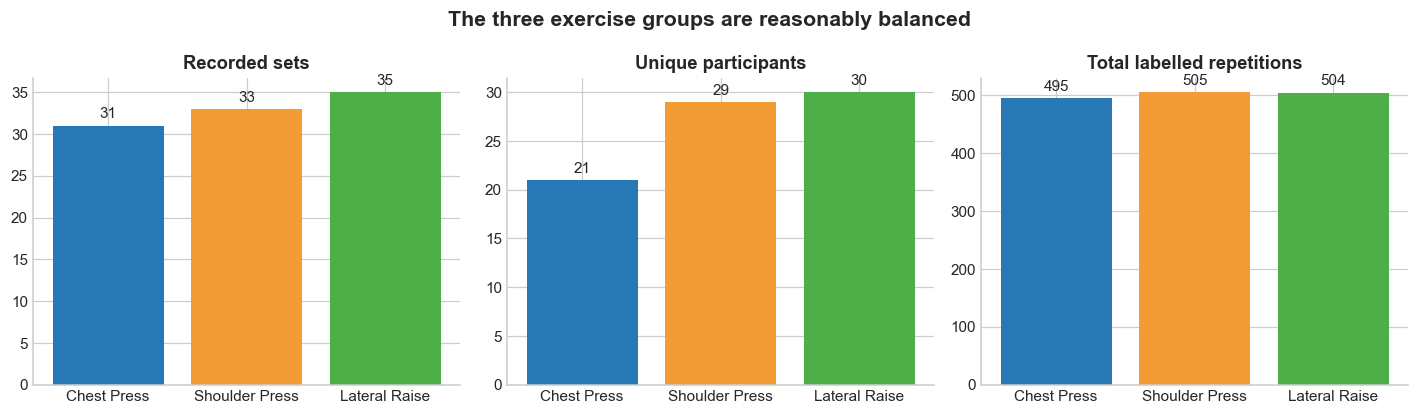

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, column, title in zip(axes, ["sets", "participants", "labelled_reps"], ["Recorded sets", "Unique participants", "Total labelled repetitions"]):
    values = overview[column]
    bars = ax.bar(range(3), values, color=[PALETTE[x] for x in EXERCISES])
    ax.set_xticks(range(3), ["Chest Press", "Shoulder Press", "Lateral Raise"])
    ax.set_title(title)
    ax.bar_label(bars, padding=3)
fig.suptitle("The three exercise groups are reasonably balanced", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## A first look at the signals

Acceleration magnitude summarizes linear movement intensity without depending on the sensor's orientation. Gyroscope magnitude summarizes rotational intensity. Direction is lost, but the plots become easier to compare across participants.

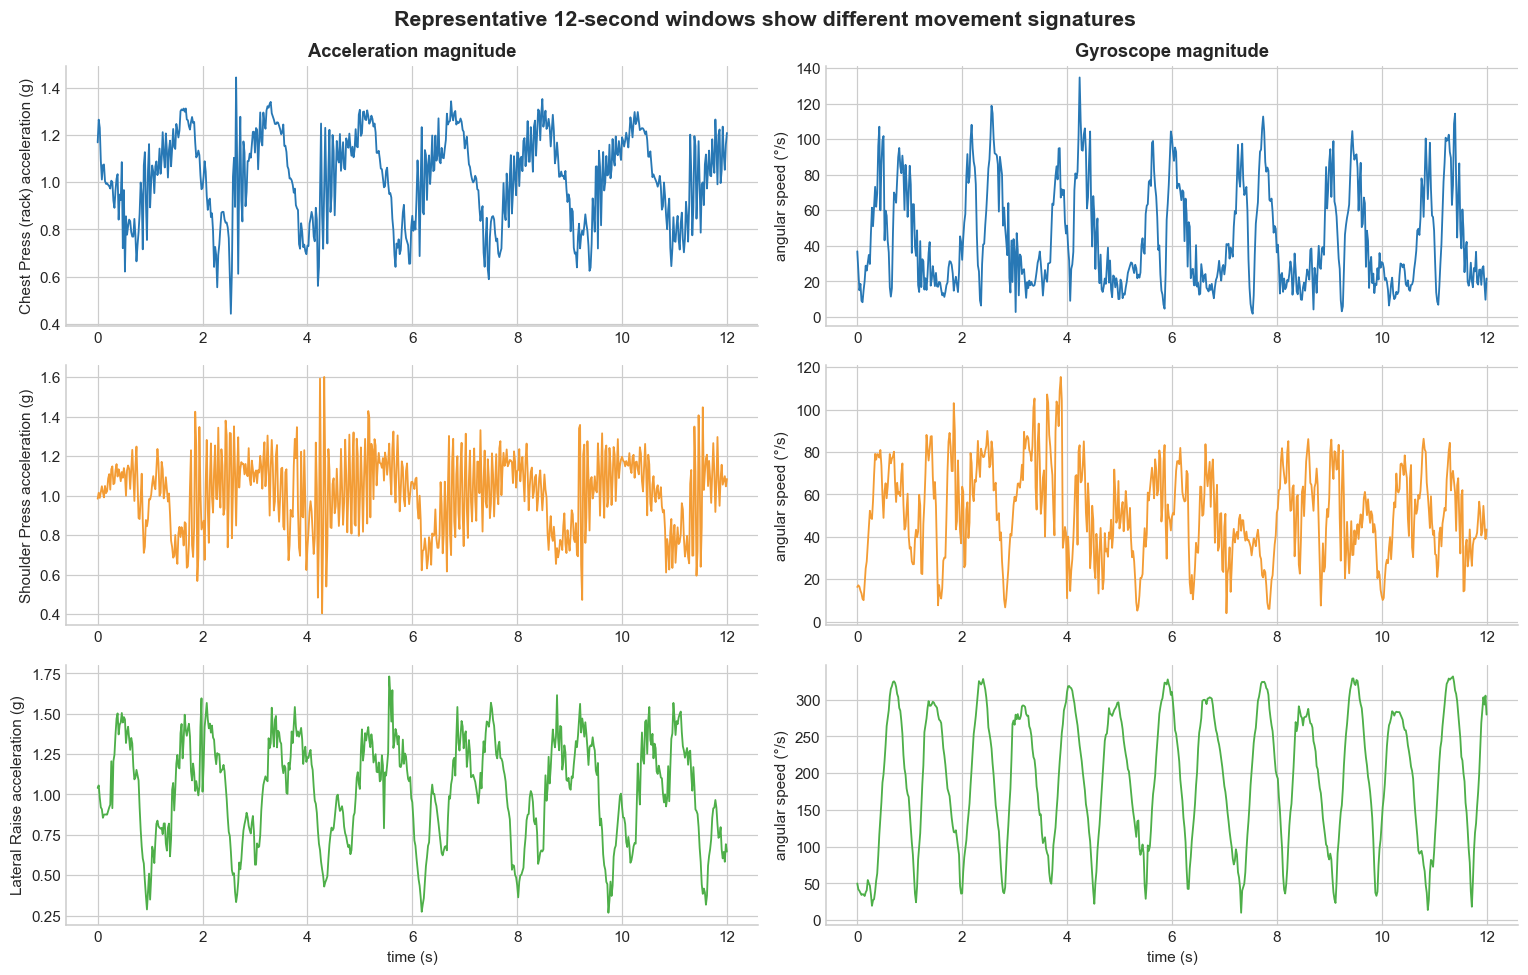

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(14, 9), sharex=False)
for row, exercise in enumerate(EXERCISES):
    uid = recordings.loc[recordings.activity_name == exercise, "record_uid"].iloc[0]
    signal = load_signal(samples, uid)
    time_s = (signal.time_s - signal.time_s.iloc[0]).to_numpy()
    mask = time_s <= 12
    accel_mag = np.linalg.norm(signal[ACC].to_numpy(), axis=1)
    gyro_mag = np.linalg.norm(signal[GYR].to_numpy(), axis=1)
    axes[row, 0].plot(time_s[mask], accel_mag[mask], color=PALETTE[exercise], lw=1.2)
    axes[row, 1].plot(time_s[mask], gyro_mag[mask], color=PALETTE[exercise], lw=1.2)
    axes[row, 0].set_ylabel(exercise.replace("Squat Rack ", "") + " acceleration (g)")
    axes[row, 1].set_ylabel("angular speed (°/s)")
axes[0, 0].set_title("Acceleration magnitude")
axes[0, 1].set_title("Gyroscope magnitude")
axes[-1, 0].set_xlabel("time (s)")
axes[-1, 1].set_xlabel("time (s)")
fig.suptitle("Representative 12-second windows show different movement signatures", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# 2. Comparing exercises with interpretable features

One feature row is created for every set. The main quantities are duration, labelled seconds per repetition, acceleration variability, dynamic acceleration RMS, gyroscope RMS, signal range, and autocorrelation-based tempo. RMS measures signal energy; autocorrelation finds the dominant repeating period.

In [5]:
recording_features = build_recording_features(recordings, samples)
recording_features.to_csv(OUTPUT_DIR / "recording_features.csv", index=False)
feature_summary = recording_features.groupby("exercise")[[
    "duration_s", "seconds_per_labelled_rep", "accel_dynamic_rms_g",
    "gyro_mag_rms_dps", "tempo_period_s"
]].median().reindex(EXERCISES).round(2)
display(feature_summary)
print(f"Median estimated sampling rate: {recording_features.sample_rate_hz.median():.2f} Hz")

,duration_s,seconds_per_labelled_rep,accel_dynamic_rms_g,gyro_mag_rms_dps,tempo_period_s
exercise,,,,,
Chest Press (rack),41.94,2.49,0.12,42.42,2.26
Squat Rack Shoulder Press,53.76,3.68,0.11,40.03,2.90
Lateral Raise,38.08,2.66,0.17,109.82,2.56


Median estimated sampling rate: 50.00 Hz


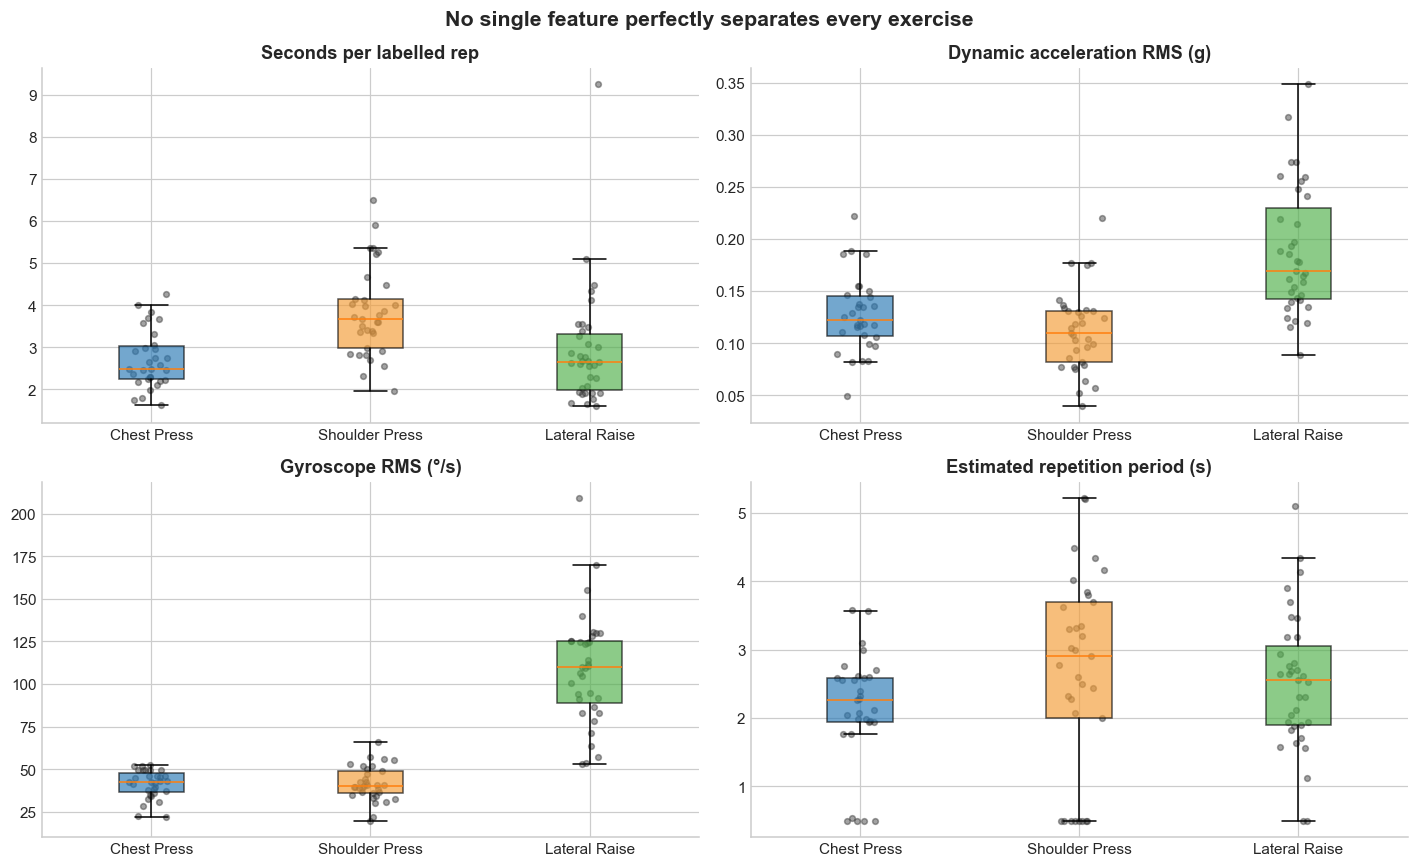

In [6]:
plot_features = ["seconds_per_labelled_rep", "accel_dynamic_rms_g", "gyro_mag_rms_dps", "tempo_period_s"]
plot_titles = ["Seconds per labelled rep", "Dynamic acceleration RMS (g)", "Gyroscope RMS (°/s)", "Estimated repetition period (s)"]
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, feature, title in zip(axes.flat, plot_features, plot_titles):
    groups = [recording_features.loc[recording_features.exercise == ex, feature].dropna() for ex in EXERCISES]
    box = ax.boxplot(groups, patch_artist=True, tick_labels=["Chest Press", "Shoulder Press", "Lateral Raise"], showfliers=False)
    for patch, exercise in zip(box["boxes"], EXERCISES):
        patch.set_facecolor(PALETTE[exercise]); patch.set_alpha(0.65)
    for index, values in enumerate(groups, start=1):
        jitter = np.random.default_rng(7 + index).normal(index, 0.045, len(values))
        ax.scatter(jitter, values, s=14, color="#333333", alpha=0.45)
    ax.set_title(title)
fig.suptitle("No single feature perfectly separates every exercise", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Three-exercise recognition check

A logistic regression combines the features. Evaluation uses five-fold cross-validation grouped by participant, so one person's sets cannot appear in both training and testing. This is stricter and more realistic than randomly splitting rows.

Fold accuracies: [0.65  0.9   0.6   0.95  0.684]
Mean subject-grouped accuracy: 0.757


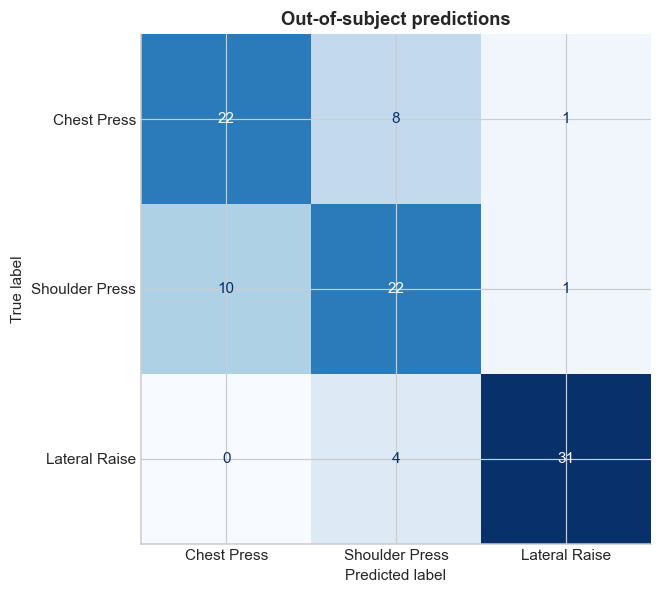

In [7]:
model_features = ["duration_s", "seconds_per_labelled_rep", "accel_mag_std_g", "accel_dynamic_rms_g", "gyro_mag_rms_dps", "dominant_accel_range_g", "tempo_period_s"]
X = recording_features[model_features]
y = recording_features.exercise
groups = recording_features.subject_id
model = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), LogisticRegression(max_iter=3000))
cv = GroupKFold(n_splits=5)
scores = cross_val_score(model, X, y, groups=groups, cv=cv)
predictions = cross_val_predict(model, X, y, groups=groups, cv=cv)
print("Fold accuracies:", np.round(scores, 3))
print(f"Mean subject-grouped accuracy: {scores.mean():.3f}")
fig, ax = plt.subplots(figsize=(6.8, 5.5))
ConfusionMatrixDisplay.from_predictions(y, predictions, labels=EXERCISES, display_labels=["Chest Press", "Shoulder Press", "Lateral Raise"], cmap="Blues", colorbar=False, ax=ax)
ax.set_title("Out-of-subject predictions")
plt.tight_layout()
plt.show()

The model is strongest on Lateral Raise, whose wide arm movement is distinctive. Chest Press and Shoulder Press are confused more often because both are pressing movements. The result is a useful baseline, not a finished recognition system.

# 3. Chest Press: splitting every push into two halves

The dominant acceleration axis is smoothed, autocorrelation estimates repetition spacing, and trough-to-peak sections are treated as pushing phases. Each push is normalized to 101 points and divided into equal first and second time halves.

Two complementary measurements are retained:

- **Dynamic acceleration RMS:** energy in acceleration magnitude after removing the static 1 g reference. Lower values mean less measured acceleration activity.
- **Signal progress rate:** how quickly the smoothed dominant-axis signal traverses its trough-to-peak range. This is a shape/rate proxy, not physical bar velocity.

In [8]:
half_features, profiles = build_chest_half_features(recordings, samples)
rep_comparison = build_rep_comparison(half_features)
set_comparison = build_set_comparison(rep_comparison)
half_features.to_csv(OUTPUT_DIR / "chest_press_half_features.csv", index=False)
rep_comparison.to_csv(OUTPUT_DIR / "chest_press_rep_comparison.csv", index=False)
set_comparison.to_csv(OUTPUT_DIR / "chest_press_set_comparison.csv", index=False)

chest_truth = recordings.loc[recordings.activity_name == CHEST, ["record_uid", "activity_reps"]]
coverage = chest_truth.merge(set_comparison[["record_uid", "detected_reps"]], on="record_uid", how="left").fillna({"detected_reps": 0})
coverage["absolute_count_error"] = (coverage.activity_reps - coverage.detected_reps).abs()
print(f"Detected pushes: {len(rep_comparison)} across {set_comparison.record_uid.nunique()} of {len(chest_truth)} sets")
print(f"Detection-count MAE: {coverage.absolute_count_error.mean():.2f} repetitions")
display(coverage.loc[coverage.detected_reps == 0])

Detected pushes: 432 across 30 of 31 sets
Detection-count MAE: 2.68 repetitions


,record_uid,activity_reps,detected_reps,absolute_count_error
2,singleonly_subject007_Chest_Press_(rack)_recor...,20,0.0,20.0


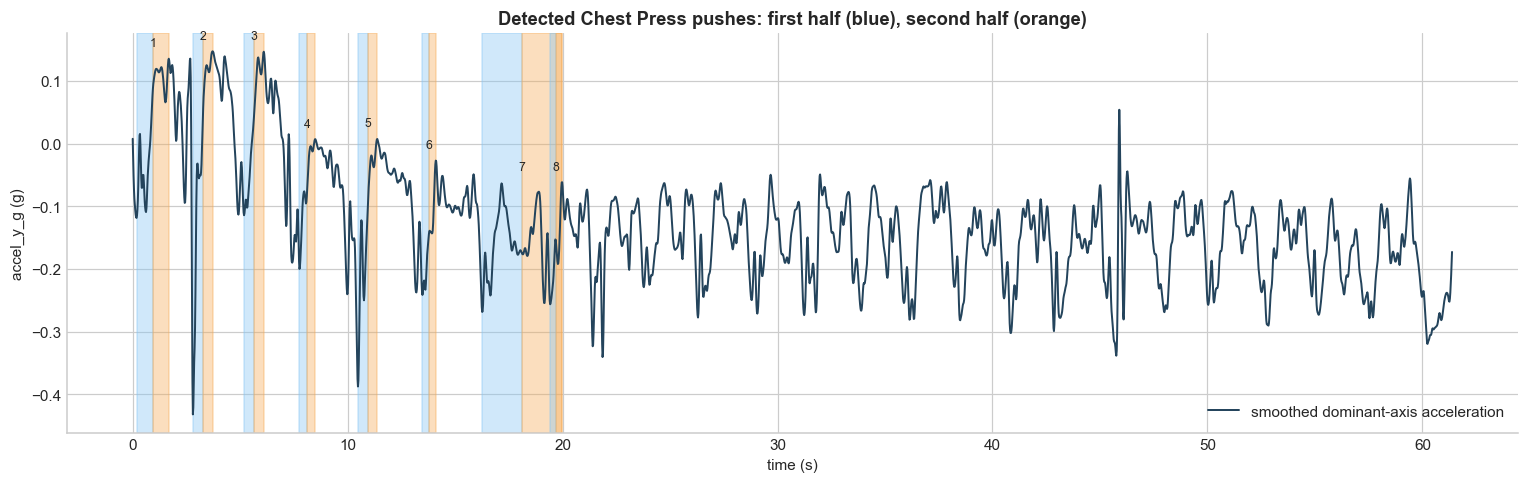

In [9]:
example_uid = set_comparison.sort_values("detected_reps", ascending=False).iloc[0].record_uid
signal = load_signal(samples, example_uid)
axis, raw, filtered, phases = detect_push_phases(signal)
time_s = (signal.time_s - signal.time_s.iloc[0]).to_numpy()
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(time_s, filtered, color="#24445C", lw=1.3, label="smoothed dominant-axis acceleration")
for rep_number, (start, end) in enumerate(phases[:8], start=1):
    midpoint = (time_s[start] + time_s[end]) / 2
    ax.axvspan(time_s[start], midpoint, color="#84C5F4", alpha=0.38)
    ax.axvspan(midpoint, time_s[end], color="#F6AA54", alpha=0.38)
    ax.text(midpoint, filtered[end] + 0.02, str(rep_number), ha="center", fontsize=8)
ax.set(xlabel="time (s)", ylabel=f"{axis} (g)", title="Detected Chest Press pushes: first half (blue), second half (orange)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 4. Within-repetition comparison

Every point below is one detected push. Points below the diagonal have lower dynamic acceleration in the second half; points above it have lower acceleration in the first half. The plot reveals both the general pattern and the large rep-to-rep variation that a single summary number would hide.

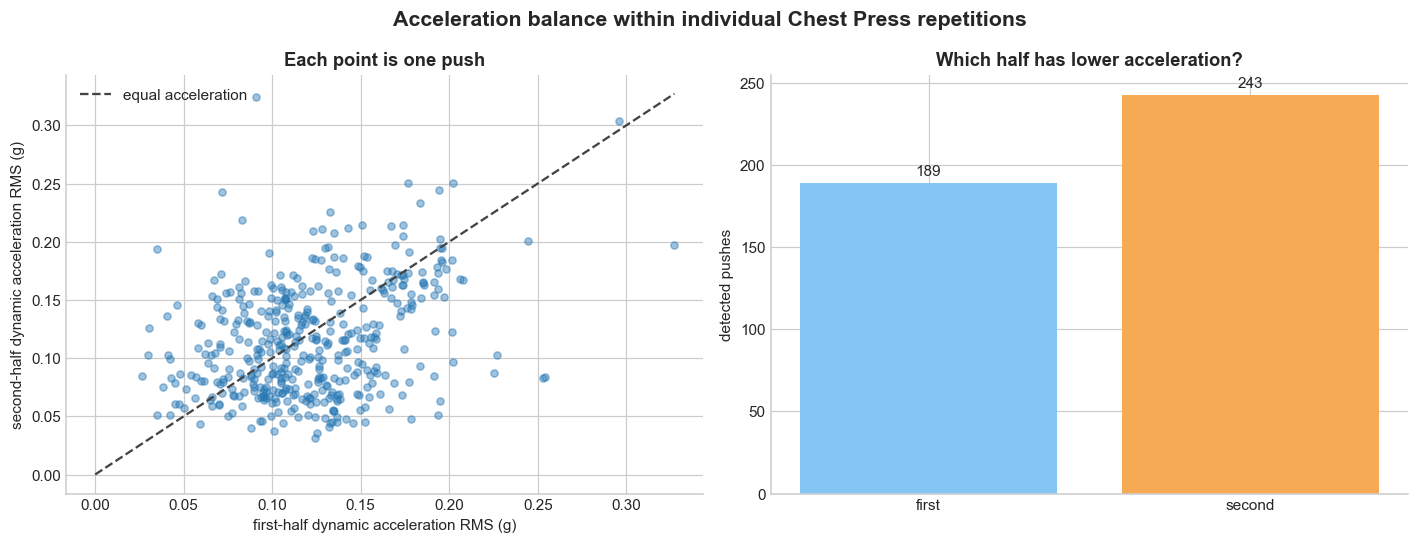

,second_to_first_accel_energy,second_to_first_progress_rate
count,432.000,432.000
mean,1.051,1.199
std,0.582,1.045
min,0.254,0.006
25%,0.689,0.537
50%,0.941,0.951
75%,1.279,1.580
max,5.564,9.222


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(rep_comparison.dynamic_accel_rms_g_first, rep_comparison.dynamic_accel_rms_g_second, s=22, alpha=0.45, color=PALETTE[CHEST])
limit = max(rep_comparison.dynamic_accel_rms_g_first.max(), rep_comparison.dynamic_accel_rms_g_second.max())
axes[0].plot([0, limit], [0, limit], "--", color="#444444", label="equal acceleration")
axes[0].set(xlabel="first-half dynamic acceleration RMS (g)", ylabel="second-half dynamic acceleration RMS (g)", title="Each point is one push")
axes[0].legend()
counts = rep_comparison.lower_acceleration_half.value_counts().reindex(["first", "second"]).fillna(0)
bars = axes[1].bar(counts.index, counts.values, color=["#84C5F4", "#F6AA54"])
axes[1].bar_label(bars, padding=3)
axes[1].set(title="Which half has lower acceleration?", ylabel="detected pushes")
fig.suptitle("Acceleration balance within individual Chest Press repetitions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
display(rep_comparison[["second_to_first_accel_energy", "second_to_first_progress_rate"]].describe().round(3))

# 5. Within-set fatigue analysis

For each set, the first 30% and last 30% of detected repetitions are compared separately for each half. A late/early energy ratio below 1 indicates reduced acceleration activity late in the set. We flag a **candidate fatigue-sensitive half** only if the reduction is at least 10%; otherwise the set is labelled `none`. The threshold is exploratory rather than clinically validated.

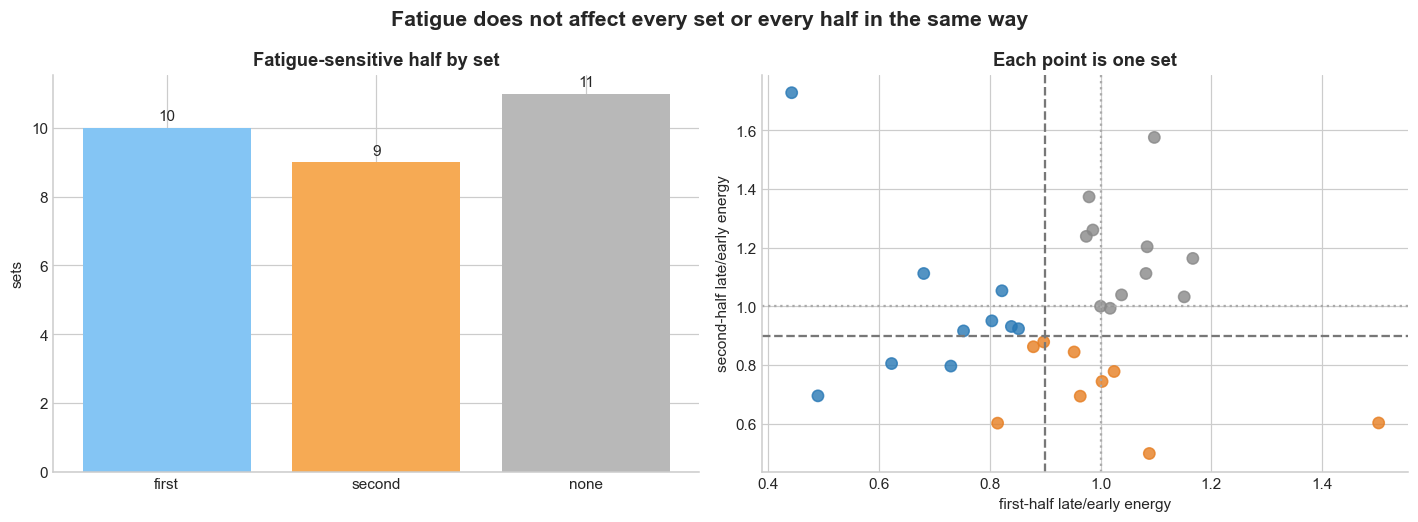

,sets
candidate_fatigue_sensitive_half,
first,10
second,9
none,11


In [11]:
candidate_counts = set_comparison.candidate_fatigue_sensitive_half.value_counts().reindex(["first", "second", "none"]).fillna(0)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
bars = axes[0].bar(candidate_counts.index, candidate_counts.values, color=["#84C5F4", "#F6AA54", "#B8B8B8"])
axes[0].bar_label(bars, padding=3)
axes[0].set(title="Fatigue-sensitive half by set", ylabel="sets")
axes[1].scatter(set_comparison.first_half_late_to_early_energy, set_comparison.second_half_late_to_early_energy, c=[{"first": "#2878B5", "second": "#E67E22", "none": "#888888"}[x] for x in set_comparison.candidate_fatigue_sensitive_half], s=55, alpha=0.8)
axes[1].axvline(0.9, ls="--", color="#777777"); axes[1].axhline(0.9, ls="--", color="#777777")
axes[1].axvline(1.0, ls=":", color="#AAAAAA"); axes[1].axhline(1.0, ls=":", color="#AAAAAA")
axes[1].set(xlabel="first-half late/early energy", ylabel="second-half late/early energy", title="Each point is one set")
fig.suptitle("Fatigue does not affect every set or every half in the same way", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
display(candidate_counts.rename("sets").to_frame())

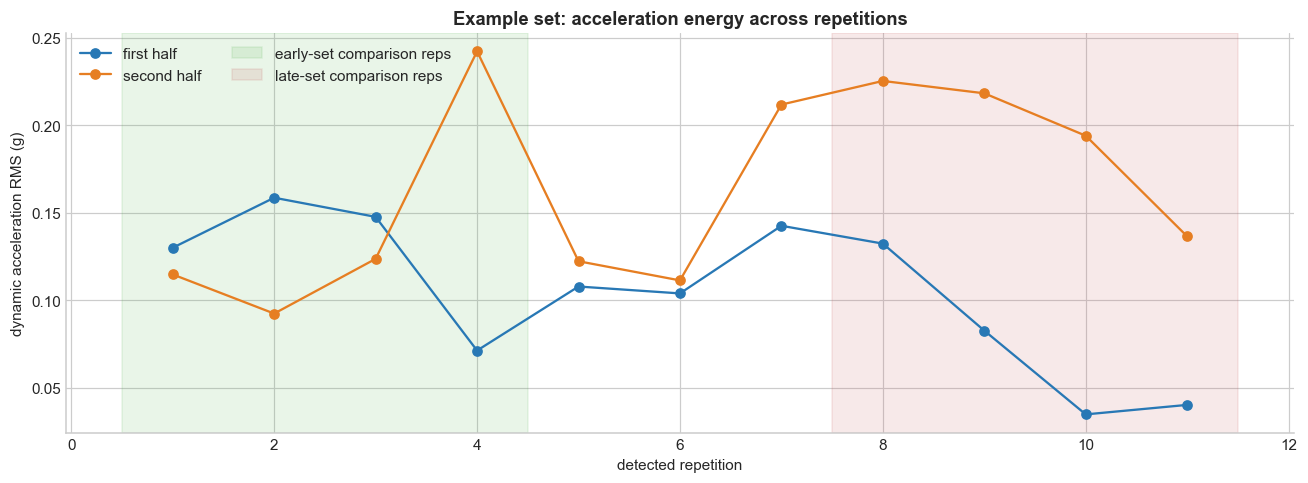

In [12]:
flagged = set_comparison.loc[set_comparison.candidate_fatigue_sensitive_half != "none"].copy()
flagged["strongest_drop"] = flagged[["first_half_late_to_early_energy", "second_half_late_to_early_energy"]].min(axis=1)
fatigue_uid = flagged.sort_values("strongest_drop").iloc[0].record_uid
example_reps = rep_comparison.loc[rep_comparison.record_uid == fatigue_uid].sort_values("rep_index")
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(example_reps.rep_index, example_reps.dynamic_accel_rms_g_first, marker="o", label="first half", color="#2878B5")
ax.plot(example_reps.rep_index, example_reps.dynamic_accel_rms_g_second, marker="o", label="second half", color="#E67E22")
edge = max(2, int(np.ceil(0.30 * len(example_reps))))
ax.axvspan(0.5, edge + 0.5, color="#4EAF49", alpha=0.12, label="early-set comparison reps")
ax.axvspan(len(example_reps) - edge + 0.5, len(example_reps) + 0.5, color="#C44E52", alpha=0.12, label="late-set comparison reps")
ax.set(xlabel="detected repetition", ylabel="dynamic acceleration RMS (g)", title="Example set: acceleration energy across repetitions")
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

# 6. Comparing among sets

Set-level medians reduce sensitivity to one noisy repetition. The first plot compares the typical acceleration energy of the two halves in every set. The second focuses on participants with multiple Chest Press recordings and connects their sets, illustrating both within-person and between-person variation.

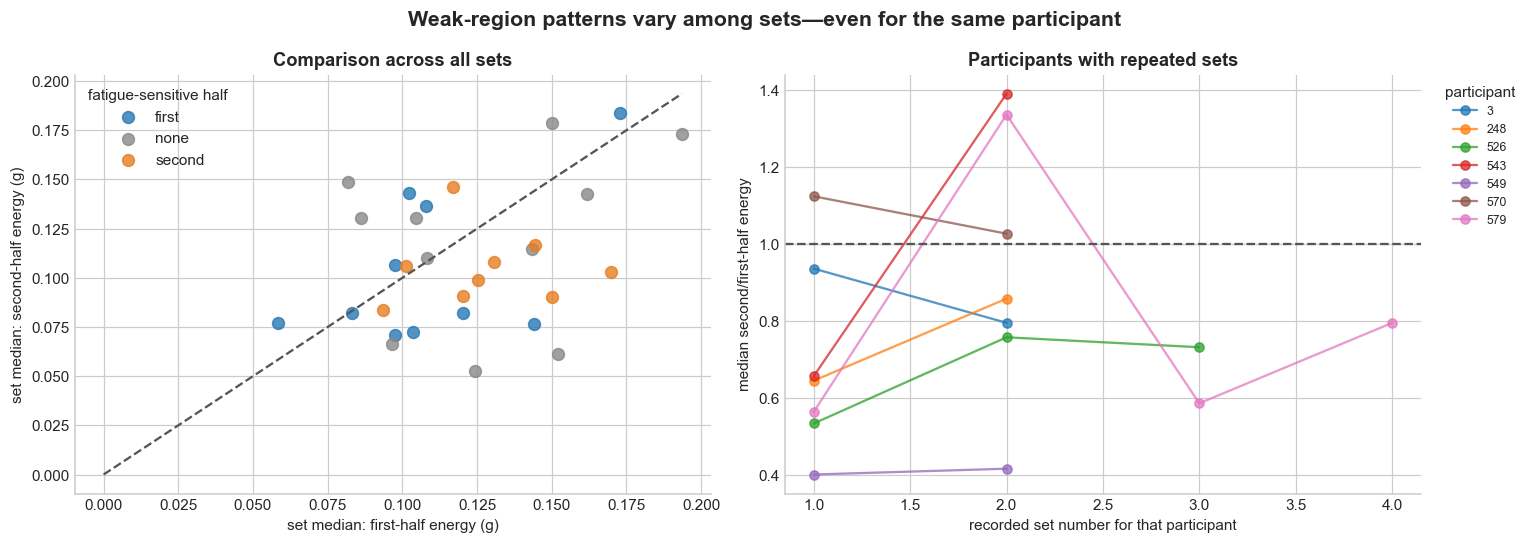

,record_uid,detected_reps,median_second_to_first_accel_energy,first_half_late_to_early_energy,second_half_late_to_early_energy,candidate_fatigue_sensitive_half
27,singleonly_subject093_Chest_Press_(rack)_recor...,2,0.402,1.000,1.000,none
28,singleonly_subject093_Chest_Press_(rack)_recor...,20,0.417,0.986,1.260,none
6,singleonly_subject052_Chest_Press_(rack)_recor...,8,0.534,0.804,0.950,first
21,singleonly_subject089_Chest_Press_(rack)_recor...,16,0.565,1.003,0.744,second
23,singleonly_subject089_Chest_Press_(rack)_recor...,14,0.587,0.879,0.862,second
10,singleonly_subject059_Chest_Press_(rack)_recor...,23,0.646,0.681,1.112,first
12,singleonly_subject069_Chest_Press_(rack)_recor...,10,0.657,0.730,0.796,first
3,singleonly_subject017_Chest_Press_(rack)_recor...,13,0.692,1.151,1.032,none
9,singleonly_subject058_Chest_Press_(rack)_recor...,14,0.731,0.822,1.053,first
8,singleonly_subject052_Chest_Press_(rack)_recor...,9,0.732,1.088,0.498,second


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
color_map = {"first": "#2878B5", "second": "#E67E22", "none": "#888888"}
for label, group in set_comparison.groupby("candidate_fatigue_sensitive_half"):
    axes[0].scatter(group.median_first_half_accel_rms_g, group.median_second_half_accel_rms_g, s=60, alpha=0.8, color=color_map[label], label=label)
limit = max(set_comparison.median_first_half_accel_rms_g.max(), set_comparison.median_second_half_accel_rms_g.max())
axes[0].plot([0, limit], [0, limit], "--", color="#555555")
axes[0].set(xlabel="set median: first-half energy (g)", ylabel="set median: second-half energy (g)", title="Comparison across all sets")
axes[0].legend(title="fatigue-sensitive half")

repeated_subjects = set_comparison.groupby("subject_id").filter(lambda frame: len(frame) > 1)
for subject_id, group in repeated_subjects.groupby("subject_id"):
    group = group.reset_index(drop=True)
    axes[1].plot(np.arange(1, len(group) + 1), group.median_second_to_first_accel_energy, marker="o", alpha=0.75, label=str(subject_id))
axes[1].axhline(1.0, ls="--", color="#555555")
axes[1].set(xlabel="recorded set number for that participant", ylabel="median second/first-half energy", title="Participants with repeated sets")
axes[1].legend(title="participant", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.suptitle("Weak-region patterns vary among sets—even for the same participant", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
display(set_comparison.sort_values("median_second_to_first_accel_energy")[["record_uid", "detected_reps", "median_second_to_first_accel_energy", "first_half_late_to_early_energy", "second_half_late_to_early_energy", "candidate_fatigue_sensitive_half"]].round(3))

# 7. Conclusions

### What the data supports

- The three exercises have visibly different IMU signatures, especially Lateral Raise versus the two pressing movements.
- Combining simple set-level features reaches **75.7% mean subject-grouped accuracy** across all three exercises.
- The method detects **432 Chest Press pushes across 30 of 31 sets**. The one complete failure is a known low-variance recording.
- The median second/first-half acceleration-energy ratio is **0.941**, but the large spread shows that the lower-acceleration half is not identical for every repetition.
- Across sets, the exploratory fatigue rule flags the first half in **10 sets**, the second half in **9 sets**, and neither half in **11 sets**. This supports personalized baselines instead of one universal weak-point threshold.

### Limitations

- Acceleration is not velocity. Double integration would drift, so the project does not claim true bar speed or position.
- Peak/trough phase boundaries are estimated rather than independently labelled.
- One low-variance Chest Press recording cannot be segmented reliably, and other sets contain counting errors.
- The 10% fatigue threshold is exploratory. No fatigue, failure, muscle activation, or anatomical weak-point ground truth exists in this dataset.
- Most participants contributed only one set, limiting conclusions about long-term individual patterns.

### Recommended next study

Record synchronized wrist IMU and side-view video or a linear position encoder. Independently label the bottom, sticking region, and lockout, and collect multiple sets per participant at different fatigue levels. That experiment could test whether the acceleration-based candidate weak region predicts an actual slowdown or failed repetition.